<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/amazon_Review_Analysis/AmazonReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Counts:
Sentiment
Positive    551
Negative     74
Neutral      14
Name: count, dtype: int64


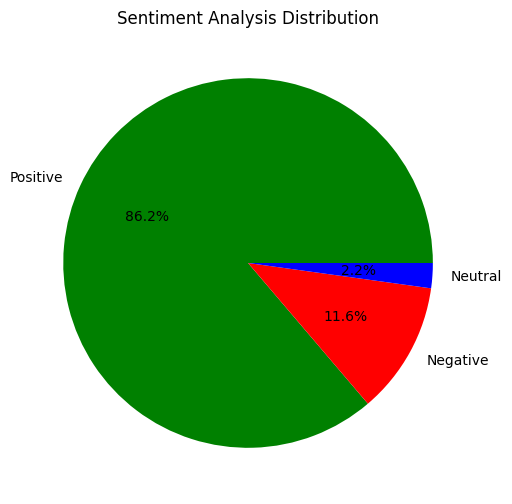

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load data from Excel file
file_path = "/content/Reviews 500.xlsx"  # Replace with your file path
df = pd.read_excel(file_path)

# Sentiment analysis function
def get_sentiment(text):
    analysis = TextBlob(str(text))  # Ensure text is string
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Text'].apply(get_sentiment)

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment Counts:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'blue'])
plt.title('Sentiment Analysis Distribution')
plt.show()

# Print sentiment counts
df[['Text', 'Sentiment']].to_csv("sentiment_output.csv", index=False)


Average Sentiment Score: 0.23
Sentiment Counts:
Sentiment
Positive    551
Negative     74
Neutral      14
Name: count, dtype: int64


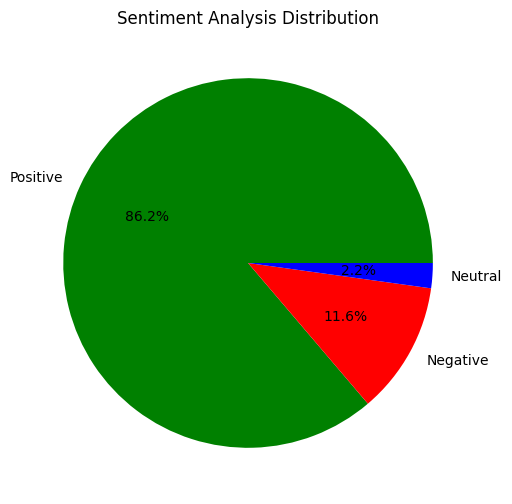

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load data from Excel file
file_path = "/content/Reviews 500.xlsx"  # Replace with your file path
df = pd.read_excel(file_path)

# Sentiment analysis function
def get_sentiment_score(text):
    analysis = TextBlob(str(text))  # Ensure text is string
    return analysis.sentiment.polarity

# Apply sentiment analysis
df['Sentiment Score'] = df['Text'].apply(get_sentiment_score)
df['Sentiment'] = df['Sentiment Score'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Calculate average sentiment score
average_sentiment = df['Sentiment Score'].mean()
print(f"Average Sentiment Score: {average_sentiment:.2f}")

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment Counts:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'blue'])
plt.title('Sentiment Analysis Distribution')
plt.show()

# Save sentiment analysis results
df[['Text', 'Sentiment Score', 'Sentiment']].to_csv("sentiment_output.csv", index=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Average Sentiment Score: 0.23
Sentiment Counts:
Sentiment
Positive    551
Negative     74
Neutral      14
Name: count, dtype: int64


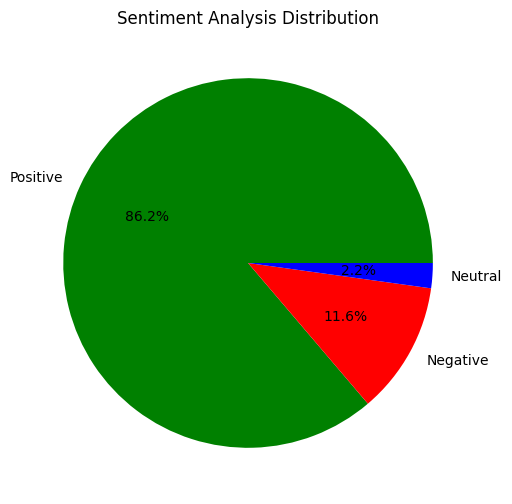

Most Common Words:
[('chips', 484), ('br', 282), ('like', 259), ('good', 206), ('great', 186), ('taste', 183), ('flavor', 181), ('one', 163), ('kettle', 162), ('love', 142)]


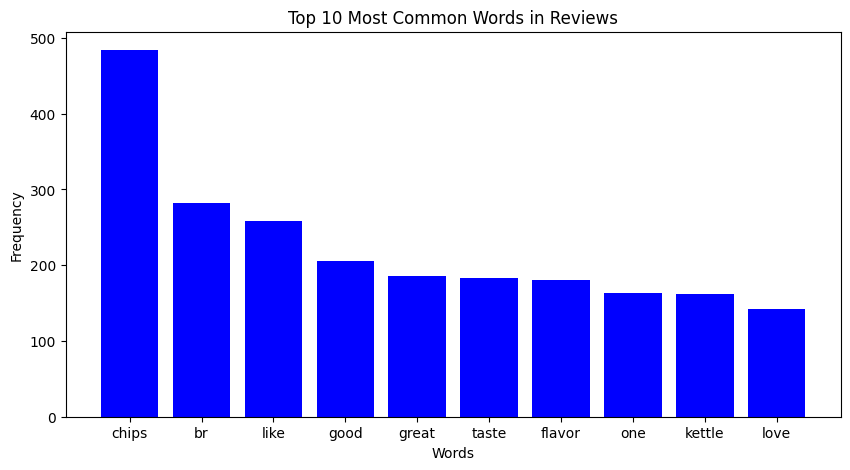

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load data from Excel file
file_path = "/content/Reviews 500.xlsx"  # Replace with your file path
df = pd.read_excel(file_path)

# Sentiment analysis function
def get_sentiment_score(text):
    analysis = TextBlob(str(text))  # Ensure text is string
    return analysis.sentiment.polarity

# Apply sentiment analysis
df['Sentiment Score'] = df['Text'].apply(get_sentiment_score)
df['Sentiment'] = df['Sentiment Score'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Calculate average sentiment score
average_sentiment = df['Sentiment Score'].mean()
print(f"Average Sentiment Score: {average_sentiment:.2f}")

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment Counts:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'blue'])
plt.title('Sentiment Analysis Distribution')
plt.show()

# Content Analysis (Word Frequency)
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return words

word_list = []
df['Text'].dropna().apply(lambda x: word_list.extend(clean_text(x)))
word_freq = Counter(word_list)

# Display most common words
common_words = word_freq.most_common(10)
print("Most Common Words:")
print(common_words)

# Plot word frequency
words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
plt.bar(words, counts, color='blue')
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Common Words in Reviews")
plt.show()

# Save sentiment analysis results
df[['Text', 'Sentiment Score', 'Sentiment']].to_csv("sentiment_output.csv", index=False)


In [ ]:
!pip install transformers



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Average Sentiment Score: 0.23
Sentiment Counts:
Sentiment
Positive    551
Negative     74
Neutral      14
Name: count, dtype: int64


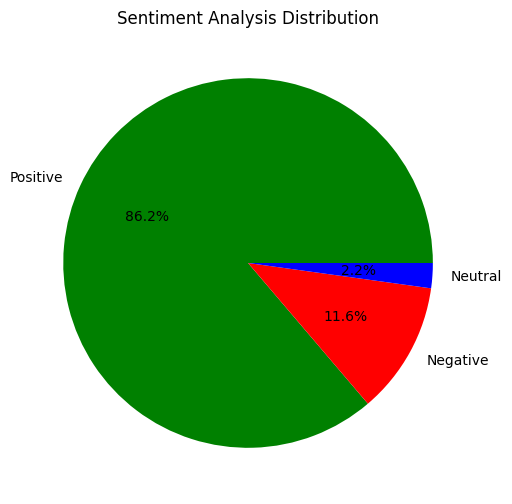

Most Common Words:
[('chips', 484), ('br', 282), ('like', 259), ('good', 206), ('great', 186), ('taste', 183), ('flavor', 181), ('one', 163), ('kettle', 162), ('love', 142)]


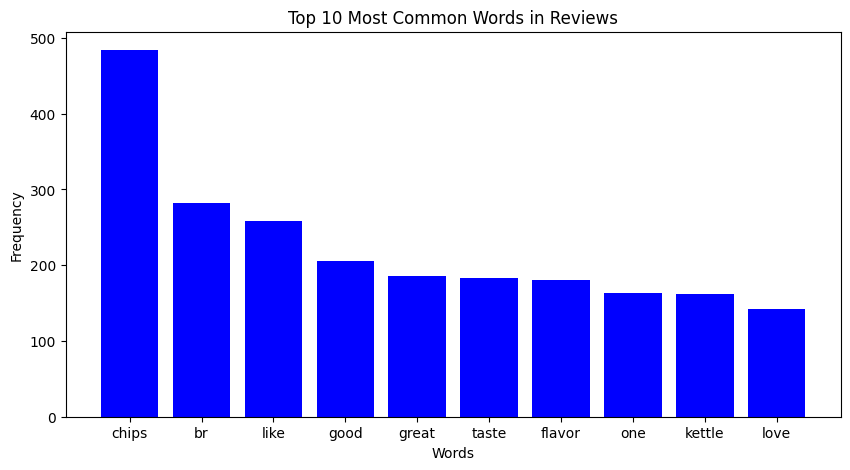

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
Token indices sequence length is longer than the specified maximum sequence length for this model (571 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The expanded size of the tensor (571) must match the existing size (514) at non-singleton dimension 1.  Target sizes: [1, 571].  Tensor sizes: [1, 514]

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
from transformers import pipeline

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load data from Excel file
file_path = "/content/Reviews 500.xlsx"  # Replace with your file path
df = pd.read_excel(file_path)

# Sentiment analysis function
def get_sentiment_score(text):
    analysis = TextBlob(str(text))  # Ensure text is string
    return analysis.sentiment.polarity

# Apply sentiment analysis
df['Sentiment Score'] = df['Text'].apply(get_sentiment_score)
df['Sentiment'] = df['Sentiment Score'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Calculate average sentiment score
average_sentiment = df['Sentiment Score'].mean()
print(f"Average Sentiment Score: {average_sentiment:.2f}")

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment Counts:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'blue'])
plt.title('Sentiment Analysis Distribution')
plt.show()

# Content Analysis (Word Frequency)
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return words

word_list = []
df['Text'].dropna().apply(lambda x: word_list.extend(clean_text(x)))
word_freq = Counter(word_list)

# Display most common words
common_words = word_freq.most_common(10)
print("Most Common Words:")
print(common_words)

# Plot word frequency
words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
plt.bar(words, counts, color='blue')
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Common Words in Reviews")
plt.show()

# Emotion analysis using Hugging Face transformers
emotion_analyzer = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

def get_emotion(text):
    result = emotion_analyzer(text)
    return result[0]['label']

# Apply emotion analysis
df['Emotion'] = df['Text'].apply(get_emotion)

# Count emotions
emotion_counts = df['Emotion'].value_counts()
print("Emotion Counts:")
print(emotion_counts)

# Plot emotion distribution
plt.figure(figsize=(6,6))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', colors=['purple', 'orange', 'cyan', 'yellow', 'pink', 'green'])
plt.title('Emotion Analysis Distribution')
plt.show()

# Save sentiment and emotion analysis results
df[['Text', 'Sentiment Score', 'Sentiment', 'Emotion']].to_csv("sentiment_and_emotion_output.csv", index=False)
